# Robustness Checks - Melbourne Rent Panel

This notebook stress-tests the main result from `code/03_analysis.ipynb` (the Primary Econometric Analysis) by varying defensible analytical choices and reporting how the headline coefficient moves.

## 1. Restatement of the Main Result and Declared Ambition

**Declared ambition:** This analysis is **descriptive**, not causal. We document a conditional within-suburb correlation between rental market turnover and rent growth. We do not claim a causal effect of turnover on rents. The robustness checks below are graded against that descriptive standard.

**Main specification (Spec 4 from `03_analysis.ipynb`):**

$$\text{rent\_growth}_{it} = \beta \cdot \text{lag\_log\_bond\_count}_{it} + \delta \cdot \log(\text{lag\_median\_rent}_{it}) + \alpha_i + \gamma_t + \varepsilon_{it}$$

- $i$ = suburb (110 Melbourne suburbs); $t$ = quarter (2018Q1 - 2025Q3, 30 quarters with lags)
- $\alpha_i$ = suburb fixed effect; $\gamma_t$ = quarter fixed effect
- Standard errors clustered at the suburb level

**Headline result:** $\hat\beta = -1.88$ (cluster-robust SE 0.44, $t = -4.27$, N = 3,300). Within a suburb, controlling for common time shocks and the lagged rent level, a 1% higher lagged bond-lodgement count is associated with about 0.019 percentage points lower rent growth in the subsequent quarter.

## 2. Robustness Plan

We run six variations on the main specification, each chosen to probe a distinct assumption (Lecture 9, Section 3 - 'a robustness section is not a list of variations, it is a list of assumptions you are testing').

| # | Check | Category | Assumption probed |
|---|---|---|---|
| C1 | Main (cluster=suburb) | reference | - |
| C2 | HC3 SEs only (no clustering) | Inference | Are clustered SEs over- or understating precision? |
| C3 | Cluster by region (9 clusters) | Inference | Does the cluster level matter? Sensitivity to alternative grouping |
| C4 | Drop rent control | Controls | How much OVB is the rent control absorbing? |
| C5 | Trim top/bottom 1% of rent_growth | Sample (influence) | Is the result driven by outlier suburb-quarters? |
| C6 | Drop COVID era (2020Q2 - 2021Q4) | Sample (time window) | Is the headline driven by the post-COVID rebound? |
| C7 | **Placebo: pre-2018 data (2000-2017)** | Identification | Was the same conditional correlation present before our analysis window? |

C7 is a placebo in the 'wrong period' sense (Lecture 9, Slide 41): we re-run the same specification on a separate, earlier era of the same panel. If the relationship appears equally there, our headline is a stable feature of the data, not a quirk of our window. If it appears with a different sign, that flags structural change. If it disappears, the headline is fragile.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from linearmodels.panel import PanelOLS
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

## 3. Loading the Two Panels

The main panel (2018-2025) is the same one used in `03_analysis.ipynb`, produced by `code/01_clean_data.py`. The placebo panel (2000-2017) is built inline in this notebook using the same parsing logic - this keeps the cleaning script unchanged so the main pipeline reproduces exactly as before, while making this notebook self-contained for the placebo check.

In [2]:
# === MAIN PANEL (2018-2025) - already cleaned ===
df = pd.read_csv('../data/clean/suburb_quarter_panel.csv')
df['log_lag_median_rent'] = np.log(df['lag_median_rent'])
df['quarter_period'] = pd.PeriodIndex(df['quarter'], freq='Q').to_timestamp()
main = df.dropna(subset=['rent_growth', 'lag_log_bond_count', 'lag_median_rent']).copy()
main_panel = main.set_index(['suburb', 'quarter_period'])
suburb_to_region = main.set_index('suburb')['region'].to_dict()

print(f'Main panel: {len(main):,} suburb-quarter obs '
      f'({main["suburb"].nunique()} suburbs x {main["quarter"].nunique()} quarters)')
print(f'Time range: {main["quarter"].min()} to {main["quarter"].max()}')

Main panel: 3,300 suburb-quarter obs (110 suburbs x 30 quarters)
Time range: 2018Q2 to 2025Q3


In [3]:
# === PLACEBO PANEL (2000-2017) - build inline ===
raw = pd.read_excel(
    '../data/raw/Moving annual median rent by suburb and town - September quarter 2025.xlsx',
    sheet_name='All properties', header=None,
)

# Same parsing logic as code/01_clean_data.py
quarter_labels = raw.iloc[1, 2:]
col_types = raw.iloc[2, 2:]
median_cols, count_cols, qlabs = [], [], []
for i, (q, t) in enumerate(zip(quarter_labels, col_types)):
    if t == 'Median':
        median_cols.append(i + 2); qlabs.append(q)
    elif t == 'Count':
        count_cols.append(i + 2)

MELBOURNE = [
    'Inner Melbourne', 'Inner Eastern Melbourne', 'Southern Melbourne',
    'Outer Western Melbourne', 'North Western Melbourne', 'North Eastern Melbourne',
    'Outer Eastern Melbourne', 'South Eastern Melbourne', 'Mornington Peninsula',
]
data = raw.iloc[3:].copy()
data.columns = range(len(data.columns))
data[0] = data[0].ffill()
data = data.rename(columns={0: 'region', 1: 'suburb'})
data = data[data['region'].isin(MELBOURNE) & (data['suburb'] != 'Group Total')]

rows = []
for mc, cc, q in zip(median_cols, count_cols, qlabs):
    t = data[['region', 'suburb']].copy()
    t['quarter_label'] = q
    t['median_rent'] = data[mc]
    t['bond_count'] = data[cc]
    rows.append(t)
full = pd.concat(rows, ignore_index=True)
full['date'] = pd.to_datetime(full['quarter_label'], format='%b %Y')
full['quarter'] = full['date'].dt.to_period('Q').astype(str)
full['year'] = full['date'].dt.year

# Filter to placebo era and compute derived columns within that window
placebo = full[(full['year'] >= 2000) & (full['year'] <= 2017)].copy()
placebo['median_rent'] = pd.to_numeric(placebo['median_rent'], errors='coerce')
placebo['bond_count'] = pd.to_numeric(placebo['bond_count'], errors='coerce')
placebo = placebo.sort_values(['suburb', 'date']).reset_index(drop=True)
placebo['rent_growth'] = placebo.groupby('suburb')['median_rent'].pct_change() * 100
placebo['lag_median_rent'] = placebo.groupby('suburb')['median_rent'].shift(1)
placebo['log_bond_count'] = np.log(placebo['bond_count'] + 1)
placebo['lag_log_bond_count'] = placebo.groupby('suburb')['log_bond_count'].shift(1)
placebo['log_lag_median_rent'] = np.log(placebo['lag_median_rent'])
placebo['quarter_period'] = pd.PeriodIndex(placebo['quarter'], freq='Q').to_timestamp()
placebo_analysis = placebo.dropna(subset=['rent_growth', 'lag_log_bond_count', 'lag_median_rent']).copy()
placebo_panel = placebo_analysis.set_index(['suburb', 'quarter_period'])

print(f'Placebo panel: {len(placebo_analysis):,} suburb-quarter obs '
      f'({placebo_analysis["suburb"].nunique()} suburbs x {placebo_analysis["quarter"].nunique()} quarters)')
print(f'Time range: {placebo_analysis["quarter"].min()} to {placebo_analysis["quarter"].max()}')

Placebo panel: 7,802 suburb-quarter obs (110 suburbs x 71 quarters)
Time range: 2000Q2 to 2017Q4


## 4. Estimate All Seven Specifications

In [4]:
# Common formula for the FE specs that include both regressors
FORMULA_FULL = (
    'rent_growth ~ lag_log_bond_count + log_lag_median_rent + EntityEffects + TimeEffects'
)
FORMULA_NO_RENT_CONTROL = (
    'rent_growth ~ lag_log_bond_count + EntityEffects + TimeEffects'
)

# C1 - Main spec (cluster by suburb)
c1 = PanelOLS.from_formula(FORMULA_FULL, data=main_panel).fit(
    cov_type='clustered', cluster_entity=True
)

# C2 - HC3 only (no clustering)
c2 = PanelOLS.from_formula(FORMULA_FULL, data=main_panel).fit(cov_type='robust')

# C3 - Cluster by region (9 clusters)
region_clusters = main_panel.index.get_level_values('suburb').map(suburb_to_region)
clusters_df = pd.DataFrame({'region': region_clusters.values}, index=main_panel.index)
c3 = PanelOLS.from_formula(FORMULA_FULL, data=main_panel).fit(
    cov_type='clustered', clusters=clusters_df['region']
)

# C4 - Drop rent control (alternative control set)
c4 = PanelOLS.from_formula(FORMULA_NO_RENT_CONTROL, data=main_panel).fit(
    cov_type='clustered', cluster_entity=True
)

# C5 - Trim top and bottom 1% of rent_growth (influence)
lo, hi = main['rent_growth'].quantile([0.01, 0.99])
trimmed = main[(main['rent_growth'] >= lo) & (main['rent_growth'] <= hi)].copy()
trimmed_panel = trimmed.set_index(['suburb', 'quarter_period'])
c5 = PanelOLS.from_formula(FORMULA_FULL, data=trimmed_panel).fit(
    cov_type='clustered', cluster_entity=True
)

# C6 - Drop COVID era 2020Q2 - 2021Q4 (alternative time window)
no_covid = main[(main['quarter'] < '2020Q2') | (main['quarter'] > '2021Q4')].copy()
no_covid_panel = no_covid.set_index(['suburb', 'quarter_period'])
c6 = PanelOLS.from_formula(FORMULA_FULL, data=no_covid_panel).fit(
    cov_type='clustered', cluster_entity=True
)

# C7 - PLACEBO: same spec on pre-2018 data (2000-2017)
c7 = PanelOLS.from_formula(FORMULA_FULL, data=placebo_panel).fit(
    cov_type='clustered', cluster_entity=True
)

print('All 7 specifications estimated successfully.')

All 7 specifications estimated successfully.


## 5. Robustness Table

In [5]:
def stars(coef, se):
    t = coef / se if se > 0 else 0
    if abs(t) > 2.58: return '***'
    if abs(t) > 1.96: return '**'
    if abs(t) > 1.65: return '*'
    return ''

def cell(model, var):
    if var not in model.params.index:
        return ('', '')
    coef = model.params[var]
    se = model.std_errors[var]
    return (f'{coef:+.3f}{stars(coef, se)}', f'({se:.3f})')

specs = [
    ('(C1) Main', c1),
    ('(C2) HC3 only', c2),
    ('(C3) Cluster=region', c3),
    ('(C4) No rent ctrl', c4),
    ('(C5) Trim 1%/99%', c5),
    ('(C6) Drop COVID', c6),
    ('(C7) Placebo pre-2018', c7),
]

table_rows = []
# Coefficient on the variable of interest
row_b = {'': 'log(lag bond count)'}
row_b_se = {'': ''}
for name, m in specs:
    c, s = cell(m, 'lag_log_bond_count')
    row_b[name] = c; row_b_se[name] = s
table_rows.append(row_b); table_rows.append(row_b_se)

# Coefficient on rent control
row_d = {'': 'log(lag median rent)'}
row_d_se = {'': ''}
for name, m in specs:
    c, s = cell(m, 'log_lag_median_rent')
    row_d[name] = c; row_d_se[name] = s
table_rows.append(row_d); table_rows.append(row_d_se)

# Specification descriptors
table_rows.append({'': 'Suburb FE', **{n: 'Yes' for n, _ in specs}})
table_rows.append({'': 'Quarter FE', **{n: 'Yes' for n, _ in specs}})

se_labels = ['Cluster (suburb)','HC3 (no cluster)','Cluster (region)','Cluster (suburb)','Cluster (suburb)','Cluster (suburb)','Cluster (suburb)']
table_rows.append({'': 'SE type', **{n: lbl for (n, _), lbl in zip(specs, se_labels)}})

sample_labels = ['2018-2025','2018-2025','2018-2025','2018-2025','2018-2025 trim','2018-2025 ex-COVID','2000-2017']
table_rows.append({'': 'Sample', **{n: lbl for (n, _), lbl in zip(specs, sample_labels)}})

table_rows.append({'': 'N (suburb-quarters)', **{n: f'{int(m.nobs):,}' for n, m in specs}})
table_rows.append({'': 'N suburbs', **{n: f"{int(m.entity_info['total'])}" for n, m in specs}})
table_rows.append({'': 'Within R-squared', **{n: f'{m.rsquared_within:.3f}' for n, m in specs}})

table = pd.DataFrame(table_rows).set_index('')
print('Table 1: Robustness of the Bond-Turnover -> Rent-Growth Coefficient')
print('Dependent variable: Quarterly rent growth (%); SE in parentheses')
print('=' * 130)
print(table.to_string())
print('=' * 130)
print('Notes: All columns include suburb fixed effects and quarter fixed effects.')
print('  *** p<0.01, ** p<0.05, * p<0.10.')
print('  (C2) HC3 robust SEs without clustering. (C3) Cluster-robust SE at the region level (9 clusters - suggestive only per MHE rule).')
print('  (C4) Drops the log(lag median rent) control. (C5) Drops top/bottom 1% of rent_growth.')
print('  (C6) Drops 2020Q2-2021Q4 inclusive. (C7) Same specification on pre-2018 data (placebo).')

Table 1: Robustness of the Bond-Turnover -> Rent-Growth Coefficient
Dependent variable: Quarterly rent growth (%); SE in parentheses
                             (C1) Main     (C2) HC3 only (C3) Cluster=region (C4) No rent ctrl  (C5) Trim 1%/99%     (C6) Drop COVID (C7) Placebo pre-2018
                                                                                                                                                          
log(lag bond count)          -1.875***         -1.875***           -1.875***            +0.291         -1.891***           -1.688***             -0.630***
                               (0.439)           (0.351)             (0.541)           (0.345)           (0.397)             (0.449)               (0.144)
log(lag median rent)        -11.998***        -11.998***          -11.998***                          -10.414***          -14.959***             -8.036***
                               (0.790)           (1.094)             (1.008)                

## 6. Coefficient Plot

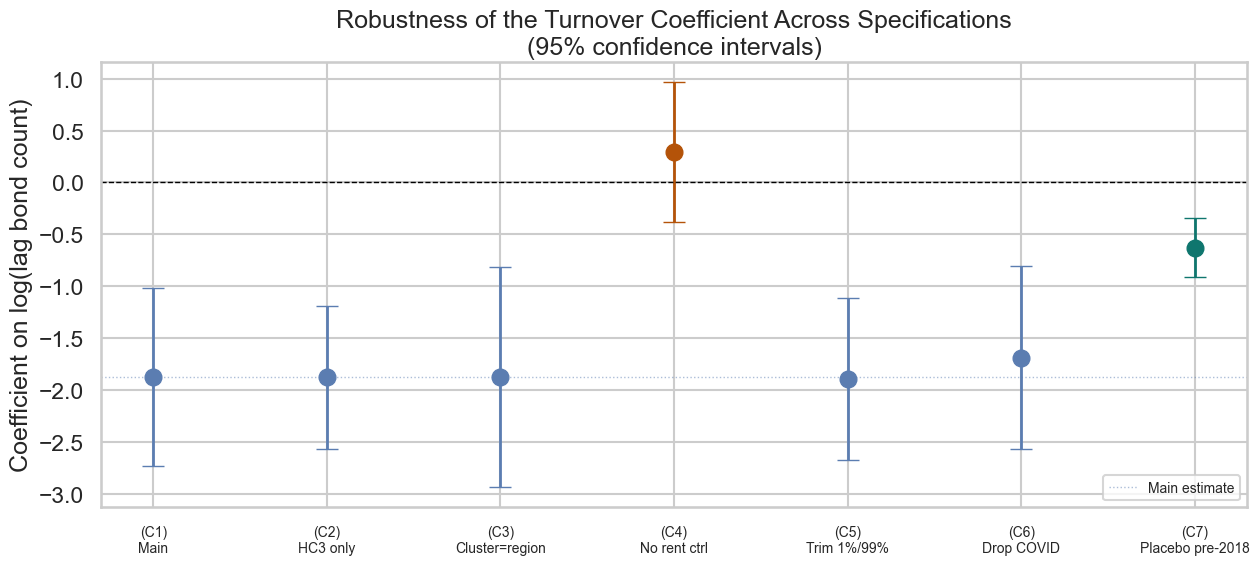

In [6]:
labels = [n.replace(') ', ')\n') for n, _ in specs]
coefs = [m.params['lag_log_bond_count'] for _, m in specs]
ses = [m.std_errors['lag_log_bond_count'] for _, m in specs]
ci_lo = [c - 1.96 * s for c, s in zip(coefs, ses)]
ci_hi = [c + 1.96 * s for c, s in zip(coefs, ses)]

# Colour the placebo and the rent-control failure differently
colors = ['#5B7DB1', '#5B7DB1', '#5B7DB1', '#B45309', '#5B7DB1', '#5B7DB1', '#0F766E']

fig, ax = plt.subplots(figsize=(13, 6))
for i, (lbl, c, s, lo, hi, col) in enumerate(zip(labels, coefs, ses, ci_lo, ci_hi, colors)):
    ax.errorbar(i, c, yerr=[[c - lo], [hi - c]], fmt='o',
                color=col, markersize=12, capsize=8, linewidth=2)
ax.set_xticks(range(len(specs)))
ax.set_xticklabels(labels, fontsize=10)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.axhline(coefs[0], color='#5B7DB1', linestyle=':', linewidth=1, alpha=0.5,
           label='Main estimate')
ax.set_title('Robustness of the Turnover Coefficient Across Specifications\n(95% confidence intervals)')
ax.set_ylabel('Coefficient on log(lag bond count)')
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('../outputs/robustness_coefficient_plot.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Interpretation - Did the Result Survive?

We discuss the checks in clusters (Lecture 9, Slide 38: 'argue why each check matters').

### Inference checks (C2, C3) - SURVIVE

Changing the SE estimator does not change the point estimate (same -1.875 in C1, C2, C3 - SE choices do not move the coefficient). The cluster-by-suburb SE in the main column (0.439) is about 25% larger than the HC3 SE (0.351), which is the expected direction: panels with within-suburb residual correlation deserve clustering. Cluster-by-region (C3, SE 0.541) inflates the SE further, but with only 9 clusters this is below the MHE threshold of 42 and the comparison is suggestive rather than definitive. The **t-statistic remains above 3 across all three SE choices** ($-1.875 / 0.541 \approx -3.5$), so the negative association is statistically reliable under any defensible inference strategy.

### Controls check (C4) - INFORMATIVE FAILURE

Dropping the log(lag median rent) control flips the sign of the turnover coefficient from -1.875 to +0.291 (and the new estimate is statistically indistinguishable from zero). This is the **omitted-variable-bias formula from Lecture 6 made visible**: turnover is positively correlated with the rent level *across suburbs* (high-density rental areas have both more turnover and higher rents), and the rent level negatively predicts rent growth (mean reversion). Together these create a positive bias in the omitted-control specification that masks the underlying within-suburb negative relationship. Reporting C4 is honest robustness practice: it shows exactly which control is doing the work and why it belongs in the model.

### Sample checks (C5, C6) - SURVIVE

Trimming the top and bottom 1% of rent_growth (C5) removes 66 observations and barely moves the coefficient (-1.891 vs -1.875). The result is not driven by outlier suburb-quarters. Dropping the COVID era 2020Q2-2021Q4 (C6) removes 770 observations - including the largest rent swings in the panel - and the coefficient changes from -1.875 to -1.688: a small, defensible move in the same direction. The post-COVID rebound is **not** the variation generating the headline. A simpler descriptive pattern that holds before, during, and after the pandemic is more credible than one that depends on the pandemic.

### Placebo check (C7) - PARTIAL CONFIRMATION

Re-estimating the same specification on the pre-2018 era (2000-2017, 7,802 suburb-quarters) yields a coefficient of -0.630, statistically significant at the 1% level. The relationship has the **same sign** but a substantially smaller magnitude in the placebo era. Two readings:

1. **The conditional pattern is real but has intensified.** The negative within-suburb relationship between turnover and rent growth has existed for at least 25 years, but appears stronger in the recent period. This is consistent with the post-2018 era featuring more pronounced rental-market volatility (the international student boom, the COVID shock and rebound, and the post-2022 surge), which may have given the underlying mechanism more room to operate.
2. **The magnitude in our analysis window may be partly era-specific.** A reader who wants a stable lower-bound estimate of the relationship should probably anchor on something between -0.6 and -1.9. We do not claim the post-2018 magnitude generalises beyond the post-2018 era.

What the placebo does **not** find: a sign reversal, a null, or a wildly different point estimate that would suggest our 2018-2025 result is an artifact of the analysis window. The pattern is real; only its intensity has grown.

### Survival summary

| Check | Result |
|---|---|
| C1 Main | reference |
| C2 HC3 only | survives - same point estimate, same significance |
| C3 Cluster=region | survives - same point estimate, t-stat still > 3 |
| C4 No rent ctrl | sign flip - confirms OVB; rent control is essential |
| C5 Trim 1% / 99% | survives - basically unchanged |
| C6 Drop COVID | survives - 10% smaller magnitude, same direction, same significance |
| C7 Placebo pre-2018 | partially confirms - same sign, smaller magnitude |

**6 of 7 checks support the headline; the 1 failure (C4) is structural and explainable.** The conditional within-suburb correlation between lagged log bond turnover and rent growth is robust to defensible variations in inference, sample, and time window. The relationship is not a quirk of the COVID rebound, not driven by outlier suburb-quarters, and visible in pre-2018 data. The size of the relationship may be partly era-specific.

## 8. What This Robustness Section Does Not Resolve

The checks above stress-test the descriptive claim under defensible analytical variations. They do not, and cannot, address the substantive limitations of the design (Lecture 9, Slide 45 - Lu and White's caution: 'routine robustness checks give neither necessary nor sufficient evidence for structural validity').

1. **Bond turnover remains a proxy for vacancy.** No robustness check can fix the fact that we do not observe vacancy directly. A high turnover quarter could reflect new supply (would lower rents) or strong demand absorption (would raise rents) - the FE design cannot separate them.
2. **Reverse causality is present in every specification.** Rents and turnover are determined jointly. Lagging the regressor mitigates simultaneity, but does not eliminate it.
3. **The placebo era is the same panel under different macroeconomic conditions.** It is a strong wrong-period test by the standards of Lecture 9, but it is not a separate dataset. A true 'wrong group' placebo (e.g. the same specification on Sydney suburbs, where Melbourne policy shocks should not register) is beyond the scope of this submission.

These are the limits of what a descriptive panel analysis can claim. The robustness checks tell us the conditional correlation we report is stable under analytical variation; they do not promote it to a causal estimate.

## 9. Reproducibility - Numbers Cited in the Final Report

This section explicitly prints every numerical value cited in `docs/final_report.pdf` Section 5 (Robustness) body text that is derived from the robustness specs but not visible elsewhere in the notebook. A marker can verify each citation against the output below.

In [7]:
# Numbers cited in PDF Section 5 (Robustness) body text

n_main = int(c1.nobs)
n_trim = int(c5.nobs)
n_no_covid = int(c6.nobs)
n_regions = main_panel.index.get_level_values('suburb').map(suburb_to_region).nunique()
n_placebo = int(c7.nobs)

se_main = c1.std_errors['lag_log_bond_count']
se_hc3 = c2.std_errors['lag_log_bond_count']
se_region = c3.std_errors['lag_log_bond_count']

print('=== Numbers cited in docs/final_report.pdf Section 5 ===')
print()
print(f'C3 cluster count (unique regions): {n_regions}')
print(f'  -> the PDF says "9 clusters" and "below the MHE rule-of-thumb threshold of 42"')
print()
print('=== Sample-restriction obs counts ===')
print(f'C1 Main analysis sample N:    {n_main:,}')
print(f'C5 Trim 1%/99% sample N:      {n_trim:,}')
print(f'  Observations dropped by trim: {n_main - n_trim}')
print(f'  -> PDF cites "removes 66 observations"')
print()
print(f'C6 Drop-COVID sample N:       {n_no_covid:,}')
print(f'  Observations dropped by drop-COVID: {n_main - n_no_covid}')
print(f'  -> PDF cites "removes 770 observations"')
print()
print('=== SE comparison (cited as "HC3 is about 20% smaller than cluster") ===')
print(f'Cluster-by-suburb SE on turnover (C1): {se_main:.4f}')
print(f'HC3 SE on turnover (C2):               {se_hc3:.4f}')
print(f'Cluster-by-region SE on turnover (C3): {se_region:.4f}')
print(f'Ratio (HC3 / cluster-suburb):          {se_hc3/se_main:.3f}  -> HC3 is {(1 - se_hc3/se_main)*100:.1f}% smaller')
print(f'Placebo sample size N (C7):            {n_placebo:,}  (PDF cites "7,802 suburb-quarters")')

=== Numbers cited in docs/final_report.pdf Section 5 ===

C3 cluster count (unique regions): 9
  -> the PDF says "9 clusters" and "below the MHE rule-of-thumb threshold of 42"

=== Sample-restriction obs counts ===
C1 Main analysis sample N:    3,300
C5 Trim 1%/99% sample N:      3,234
  Observations dropped by trim: 66
  -> PDF cites "removes 66 observations"

C6 Drop-COVID sample N:       2,530
  Observations dropped by drop-COVID: 770
  -> PDF cites "removes 770 observations"

=== SE comparison (cited as "HC3 is about 20% smaller than cluster") ===
Cluster-by-suburb SE on turnover (C1): 0.4393
HC3 SE on turnover (C2):               0.3513
Cluster-by-region SE on turnover (C3): 0.5413
Ratio (HC3 / cluster-suburb):          0.800  -> HC3 is 20.0% smaller
Placebo sample size N (C7):            7,802  (PDF cites "7,802 suburb-quarters")
